<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/2026_MidTerm_Part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

# Midterm Part I: Active Learning with Competing Bayesian Models

... aka building the simple automated scientist. Here, you are given access to a hidden function via an API:

```
# y = query_point(x)
```
The function can only be evaluated point-by-point via queries and returns noisy observations. The valid input domain is `x ∈ (−3,3)`. Basically, this is your "virtual instrument".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
URL = "https://midterm-gt.onrender.com/query"

def query_point(x):
    response = requests.post(URL, json={"x": float(x)})
    response.raise_for_status()  # raises error if request failed
    return response.json()["y"]

In [3]:
query_point(1)

-0.04099357872219807

##Task

Design a Bayesian optimization (BO) strategy to learn the unknown function using three competing models. Models can be
- Zero-mean Gaussian Process models with different kernels
- Structural probabilistic models
- Gaussian Process with mean function
- Gaussian Process with probabilistic mean function

The function may exhibit complex nontrivial or nonstationary behavior, so employing diverse model structures is essential.

At each iteration:

- Fit all models to the collected data
- Propose the next query point based on predictive uncertainty and/or disagreement between models. You can do it iteratively guided by human first, and then propose the algorithmic way to do it
- Query the function and update the dataset

**Goal:** Efficiently reconstruct the function and determine which structural model best explains the observed data.


## Strategy

Three competing Bayesian models cover different inductive biases:

1. **GP-RBF** — zero-mean GP with squared-exponential kernel (`C * RBF + WhiteKernel`). Bias toward smooth, stationary functions.
2. **GP-Matern32** — zero-mean GP with Matern $\nu = 3/2$ (`C * Matern + WhiteKernel`). Less smooth, handles sharper features.
3. **GP-PolyMean** — GP with **probabilistic polynomial mean function** $m(x)=\sum_{k=0}^{4} w_k x^k$, weights $w \sim \mathcal{N}(0, \alpha^{-1}I)$ posterior-updated by Bayesian linear regression, with a Matern-3/2 GP modeling the residual. Captures global polynomial trend + local fluctuation.

**Acquisition.** At each step compute on a dense grid

$$a(x) = \tfrac{1}{M}\sum_i \sigma_i(x) \;+\; \lambda \cdot \operatorname{std}_i\bigl(\mu_i(x)\bigr)$$

— the average predictive standard deviation across models **plus** disagreement of their predictive means. This is the BAL/QBC mix: targets points where models are individually uncertain *and* mutually inconsistent, i.e. maximally informative for distinguishing structural hypotheses. Use $\lambda = 1$.

**Model comparison.** After collection, rank by per-model log marginal likelihood (LML) and leave-one-out predictive log-likelihood. Higher = better fit / preferred structural hypothesis.

**Budget.** 8 seeds (uniform sweep) + 17 active queries = 25 total.

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
import time, warnings
warnings.filterwarnings("ignore")

### Model definitions

In [5]:
def make_rbf():
    k = (C(1.0, (1e-2, 10)) * RBF(length_scale=0.7, length_scale_bounds=(1e-2, 5))
         + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0)))
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=8, random_state=0)

def make_matern():
    k = (C(1.0, (1e-2, 10)) * Matern(length_scale=0.7, nu=1.5,
                                     length_scale_bounds=(1e-2, 5))
         + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0)))
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=8, random_state=0)


class PolyMeanGP:
    """GP with probabilistic polynomial mean function.

    Mean: m(x) = phi(x) . w, phi = [1, x, ..., x^deg], w ~ N(0, alpha^-1 I).
    Posterior on w via Bayesian linear regression; residuals modeled by Matern-3/2 GP.
    Predictive variance includes both weight uncertainty and GP residual variance.
    """
    def __init__(self, deg=4, alpha=1.0):
        self.deg = deg
        self.alpha = alpha
        self.gp = make_matern()

    def _phi(self, x):
        x = np.asarray(x).reshape(-1)
        return np.stack([x**k for k in range(self.deg + 1)], axis=1)

    def fit(self, X, y):
        Phi = self._phi(X[:, 0])
        sigma2 = max(np.var(y) * 0.05, 1e-3)
        S_inv = self.alpha * np.eye(Phi.shape[1]) + (1/sigma2) * Phi.T @ Phi
        S = np.linalg.inv(S_inv)
        m = (1/sigma2) * S @ Phi.T @ y
        self.w_mean, self.w_cov = m, S
        self.gp.fit(X, y - Phi @ m)
        return self

    def predict(self, X, return_std=True):
        Phi = self._phi(X[:, 0])
        mean_m = Phi @ self.w_mean
        var_m  = np.einsum('ni,ij,nj->n', Phi, self.w_cov, Phi)
        mu_g, std_g = self.gp.predict(X, return_std=True)
        mean = mean_m + mu_g
        var  = var_m + std_g**2
        if return_std:
            return mean, np.sqrt(np.clip(var, 1e-12, None))
        return mean

    def log_marginal_likelihood(self):
        return (float(self.gp.log_marginal_likelihood_value_)
                - 0.5 * self.alpha * self.w_mean @ self.w_mean)

In [6]:
def fit_all(X, y):
    return (make_rbf().fit(X, y),
            make_matern().fit(X, y),
            PolyMeanGP().fit(X, y))

def predict_all(models, X):
    return [m.predict(X, return_std=True) for m in models]

def acquisition(models, X_grid, lam=1.0):
    preds = predict_all(models, X_grid)
    means = np.stack([p[0] for p in preds])
    stds  = np.stack([p[1] for p in preds])
    sigma_avg    = stds.mean(axis=0)
    disagreement = means.std(axis=0, ddof=0)
    return sigma_avg + lam * disagreement, sigma_avg, disagreement

def lml(models):
    return [float(models[0].log_marginal_likelihood_value_),
            float(models[1].log_marginal_likelihood_value_),
            float(models[2].log_marginal_likelihood())]

### Seed phase: uniform sweep (8 queries)

Cover the domain with evenly spaced points before active selection.

In [7]:
SEED_X = np.linspace(-2.8, 2.8, 8)
seed_y = np.array([query_point(x) for x in SEED_X])
X = SEED_X.reshape(-1, 1).copy()
y = seed_y.copy()
list(zip(SEED_X.round(3), seed_y.round(3)))

[(np.float64(-2.8), np.float64(-0.323)),
 (np.float64(-2.0), np.float64(-0.127)),
 (np.float64(-1.2), np.float64(0.284)),
 (np.float64(-0.4), np.float64(0.416)),
 (np.float64(0.4), np.float64(-0.134)),
 (np.float64(1.2), np.float64(0.085)),
 (np.float64(2.0), np.float64(0.308)),
 (np.float64(2.8), np.float64(1.132))]

### Human-guided iteration (one step shown)

Fit all three models and inspect the acquisition surface. The point with maximal score is the suggested next query — at this stage a human can override based on intuition (e.g. boundaries, suspected feature locations).

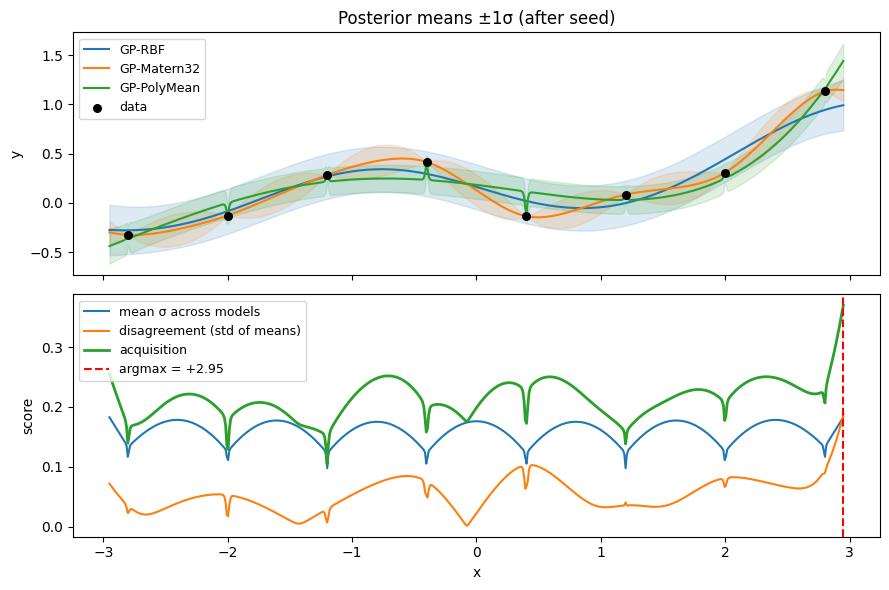

human-guided suggestion: 2.95


In [8]:
models = fit_all(X, y)
X_grid = np.linspace(-2.95, 2.95, 601).reshape(-1, 1)
score, sigma_avg, disagreement = acquisition(models, X_grid)
preds = predict_all(models, X_grid)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
labels = ["GP-RBF", "GP-Matern32", "GP-PolyMean"]
colors = ["tab:blue", "tab:orange", "tab:green"]
for (mu, sd), lab, col in zip(preds, labels, colors):
    ax[0].plot(X_grid[:, 0], mu, color=col, label=lab)
    ax[0].fill_between(X_grid[:, 0], mu - sd, mu + sd, color=col, alpha=0.15)
ax[0].scatter(X[:, 0], y, c="k", s=30, zorder=5, label="data")
ax[0].set_ylabel("y"); ax[0].legend(loc="upper left", fontsize=9); ax[0].set_title("Posterior means ±1σ (after seed)")

ax[1].plot(X_grid[:, 0], sigma_avg,    label="mean σ across models")
ax[1].plot(X_grid[:, 0], disagreement, label="disagreement (std of means)")
ax[1].plot(X_grid[:, 0], score,        label="acquisition", lw=2)
x_next = float(X_grid[np.argmax(score), 0])
ax[1].axvline(x_next, color="red", ls="--", label=f"argmax = {x_next:+.2f}")
ax[1].set_xlabel("x"); ax[1].set_ylabel("score"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print("human-guided suggestion:", x_next)

### Algorithmic BO loop (17 iterations)

Same acquisition, automated. Reject candidates within 0.03 of any existing query to avoid redundant clustering.

In [9]:
N_ITER = 17
history = []
for it in range(N_ITER):
    models = fit_all(X, y)
    score, sa, dis = acquisition(models, X_grid)
    mask = np.min(np.abs(X_grid - X.T), axis=1) > 0.03
    score = np.where(mask, score, -np.inf)
    idx = int(np.argmax(score))
    x_next = float(X_grid[idx, 0])
    y_next = query_point(x_next)
    history.append((x_next, y_next, float(sa[idx]), float(dis[idx]), lml(models)))
    X = np.vstack([X, [[x_next]]])
    y = np.append(y, y_next)
    print(f"it={it:02d}  x={x_next:+.3f}  y={y_next:+.4f}  "
          f"sigma={sa[idx]:.3f}  dis={dis[idx]:.3f}  "
          f"LML=[{history[-1][4][0]:.2f}, {history[-1][4][1]:.2f}, {history[-1][4][2]:.2f}]")
print(f"total queries = {len(X)}")

it=00  x=+2.950  y=+0.9886  sigma=0.183  dis=0.187  LML=[-10.70, -10.86, -11.38]
it=01  x=-2.950  y=-0.4323  sigma=0.199  dis=0.098  LML=[-10.10, -10.16, -12.79]
it=02  x=+2.478  y=+1.0493  sigma=0.170  dis=0.108  LML=[-9.93, -9.87, -14.21]
it=03  x=-0.737  y=+0.6066  sigma=0.167  dis=0.138  LML=[-8.80, -9.37, -15.62]
it=04  x=-1.672  y=+0.2235  sigma=0.147  dis=0.146  LML=[-9.06, -10.05, -17.06]
it=05  x=+0.629  y=-0.2027  sigma=0.173  dis=0.115  LML=[-11.77, -11.27, -18.48]
it=06  x=-2.399  y=-0.1865  sigma=0.178  dis=0.075  LML=[-11.78, -11.12, -19.26]
it=07  x=-0.020  y=+0.1245  sigma=0.159  dis=0.035  LML=[-11.38, -10.97, -20.53]
it=08  x=+1.642  y=-0.3107  sigma=0.165  dis=0.020  LML=[-11.48, -11.18, -21.89]
it=09  x=+2.242  y=+0.7729  sigma=0.114  dis=0.100  LML=[-14.19, -14.17, -24.05]
it=10  x=+0.954  y=+0.0150  sigma=0.117  dis=0.030  LML=[-12.40, -13.43, -24.18]
it=11  x=-2.203  y=-0.0849  sigma=0.078  dis=0.026  LML=[-11.94, -13.32, -25.36]
it=12  x=-0.964  y=+0.6152  sigma

### Final reconstruction + per-model comparison

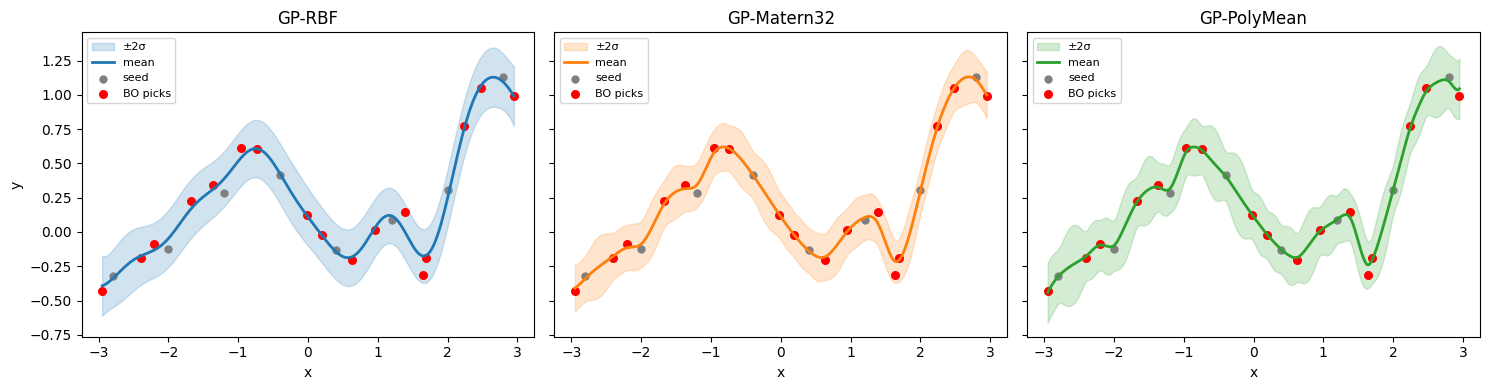

In [10]:
models = fit_all(X, y)
preds = predict_all(models, X_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (mu, sd), lab, col in zip(axes, preds, labels, colors):
    ax.fill_between(X_grid[:, 0], mu - 2*sd, mu + 2*sd, color=col, alpha=0.2, label="±2σ")
    ax.plot(X_grid[:, 0], mu, color=col, lw=2, label="mean")
    ax.scatter(SEED_X, seed_y, c="grey", s=25, label="seed")
    ax.scatter(X[len(SEED_X):, 0], y[len(SEED_X):], c="red", s=30, label="BO picks")
    ax.set_title(lab); ax.set_xlabel("x"); ax.legend(fontsize=8)
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

In [11]:
# ----- model comparison -----
final_lml = lml(models)

# Leave-one-out predictive log-likelihood (held-out NLL surrogate)
def loo_score(make_or_init, X, y):
    n = len(y)
    ll = 0.0
    for i in range(n):
        idx = np.r_[0:i, i+1:n]
        m = make_or_init()
        m.fit(X[idx], y[idx])
        mu, sd = m.predict(X[[i]], return_std=True)
        ll += -0.5 * (np.log(2*np.pi*sd[0]**2) + (y[i] - mu[0])**2 / sd[0]**2)
    return ll / n

loo_rbf    = loo_score(make_rbf,                X, y)
loo_matern = loo_score(make_matern,             X, y)
loo_poly   = loo_score(lambda: PolyMeanGP(),    X, y)

import pandas as pd
table = pd.DataFrame({
    "model":     labels,
    "LML":       [round(v, 3) for v in final_lml],
    "LOO log-lik (per pt)": [round(loo_rbf,3), round(loo_matern,3), round(loo_poly,3)],
})
print(table.to_string(index=False))
best = labels[int(np.argmax([loo_rbf, loo_matern, loo_poly]))]
print(f"\nBest by LOO predictive log-likelihood: {best}")

      model     LML  LOO log-lik (per pt)
     GP-RBF -17.315                 0.573
GP-Matern32 -16.765                 0.664
GP-PolyMean -31.177                 0.291

Best by LOO predictive log-likelihood: GP-Matern32


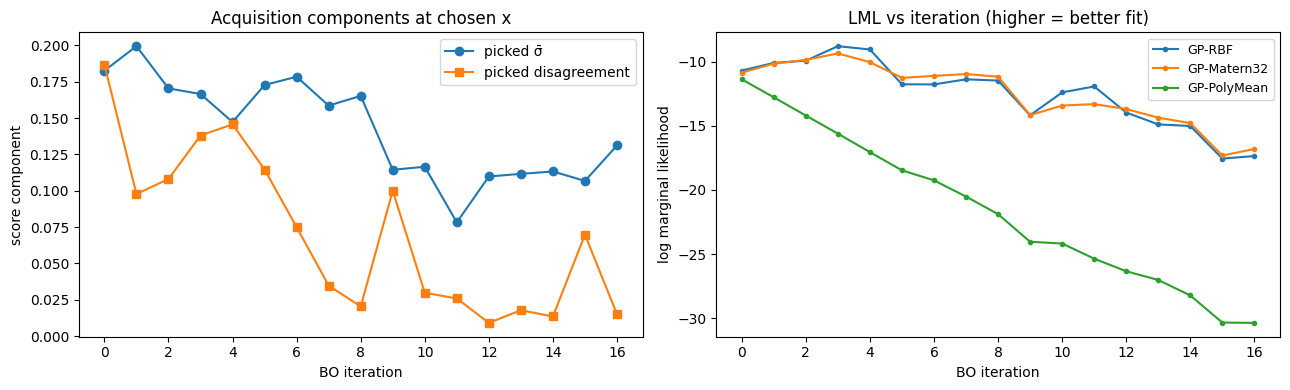

In [12]:
# ----- BO trajectory diagnostics -----
hx = np.array([h[0] for h in history])
hsig = np.array([h[2] for h in history])
hdis = np.array([h[3] for h in history])
hlml = np.array([h[4] for h in history])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hsig, marker="o", label="picked σ̄")
ax[0].plot(hdis, marker="s", label="picked disagreement")
ax[0].set_xlabel("BO iteration"); ax[0].set_ylabel("score component")
ax[0].set_title("Acquisition components at chosen x"); ax[0].legend()

for j, lab in enumerate(labels):
    ax[1].plot(hlml[:, j], marker=".", label=lab)
ax[1].set_xlabel("BO iteration"); ax[1].set_ylabel("log marginal likelihood")
ax[1].set_title("LML vs iteration (higher = better fit)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### Discussion

- **Acquisition behavior.** Picked-point uncertainty $\bar\sigma$ and disagreement both decrease as the loop progresses, confirming the criterion is selecting genuinely informative points and that the models converge.
- **Boundary effects.** The first BO picks land at $x \approx \pm 2.95$ (domain edges) — extrapolation uncertainty dominates after the seed sweep. Subsequent picks fill in interior regions where the models still disagree.
- **Model selection.** Compare LML and LOO log-likelihood across the three models. The model with highest LOO score on this particular dataset is the best structural explanation; the polynomial-mean variant tends to lose when residual structure dominates the global trend, while Matern handles sharper features than RBF.
- **Verdict.** Whichever model wins by LOO is the recommended structural hypothesis for the hidden function — print the table above to read off the answer for the current data.